In [8]:
!pip install sentence-transformers -q

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("All imports loaded successfully.")

All imports loaded successfully.


In [ ]:
sentences = [
    # Cricket — 4 sentences
    "The batsman hit a six over the boundary rope.",
    "India won the test match by an innings and 50 runs.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "Rain interrupted play on the third day of the match.",
    # Cooking — 3 sentences
    "Sauté the onions in olive oil until they turn golden brown.",
    "Preheat the oven to 180 degrees before placing the cake inside.",
    "Add a pinch of salt and freshly ground pepper to the soup.",
    # Cybersecurity — 3 sentences
    "The hacker used a phishing email to steal login credentials.",
    "End-to-end encryption ensures only the sender and receiver can read the message.",
    "A firewall monitors and filters incoming and outgoing network traffic.",
]

topic_labels = (["Cricket"] * 4) + (["Cooking"] * 3) + (["Cybersecurity"] * 3)

print(f"{len(sentences)} sentences loaded across 3 topics:\n")
for topic, start, end in [
    ("Cricket", 0, 4),
    ("Cooking", 4, 7),
    ("Cybersecurity", 7, 10),
]:
    print(f"{topic} ({end - start} sentences):")
    for i in range(start, end):
        print(f"  S{i+1:02d}: {sentences[i]}")
    print()

10 sentences loaded across 3 topics:

🏏 Cricket (4 sentences):
  S01: The batsman hit a six over the boundary rope.
  S02: India won the test match by an innings and 50 runs.
  S03: The spinner bowled a perfect googly to dismiss the opener.
  S04: Rain interrupted play on the third day of the match.

🍳 Cooking (3 sentences):
  S05: Sauté the onions in olive oil until they turn golden brown.
  S06: Preheat the oven to 180 degrees before placing the cake inside.
  S07: Add a pinch of salt and freshly ground pepper to the soup.

🔐 Cybersecurity (3 sentences):
  S08: The hacker used a phishing email to steal login credentials.
  S09: End-to-end encryption ensures only the sender and receiver can read the message.
  S10: A firewall monitors and filters incoming and outgoing network traffic.



In [11]:
print("Loading model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded. Generating embeddings for 10 sentences...")

embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")
print("Each sentence is represented as a 384-dimensional vector.")

Loading model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Generating embeddings for 10 sentences...
Embedding shape: (10, 384)
Each sentence is represented as a 384-dimensional vector.


In [12]:
sim_matrix = cosine_similarity(embeddings)
labels = [f"S{i+1:02d}" for i in range(10)]

print("10×10 Cosine Similarity Matrix:\n")
header = "        " + "  ".join(labels)
print(header)
for i, row in enumerate(sim_matrix):
    vals = "  ".join(f"{v:+.3f}" for v in row)
    print(f"{labels[i]}   {vals}")


10×10 Cosine Similarity Matrix:

        S01  S02  S03  S04  S05  S06  S07  S08  S09  S10
S01   +1.000  +0.420  +0.348  +0.184  -0.035  +0.055  +0.003  +0.079  -0.001  +0.044
S02   +0.420  +1.000  +0.321  +0.254  +0.020  +0.033  -0.024  +0.083  -0.014  +0.118
S03   +0.348  +0.321  +1.000  +0.248  +0.118  +0.053  +0.103  +0.082  +0.062  +0.062
S04   +0.184  +0.254  +0.248  +1.000  -0.002  -0.023  +0.088  +0.049  +0.069  +0.079
S05   -0.035  +0.020  +0.118  -0.002  +1.000  +0.299  +0.446  +0.029  -0.032  -0.057
S06   +0.055  +0.033  +0.053  -0.023  +0.299  +1.000  +0.169  +0.099  +0.079  -0.071
S07   +0.003  -0.024  +0.103  +0.088  +0.446  +0.169  +1.000  -0.022  -0.056  -0.028
S08   +0.079  +0.083  +0.082  +0.049  +0.029  +0.099  -0.022  +1.000  +0.127  +0.119
S09   -0.001  -0.014  +0.062  +0.069  -0.032  +0.079  -0.056  +0.127  +1.000  +0.216
S10   +0.044  +0.118  +0.062  +0.079  -0.057  -0.071  -0.028  +0.119  +0.216  +1.000


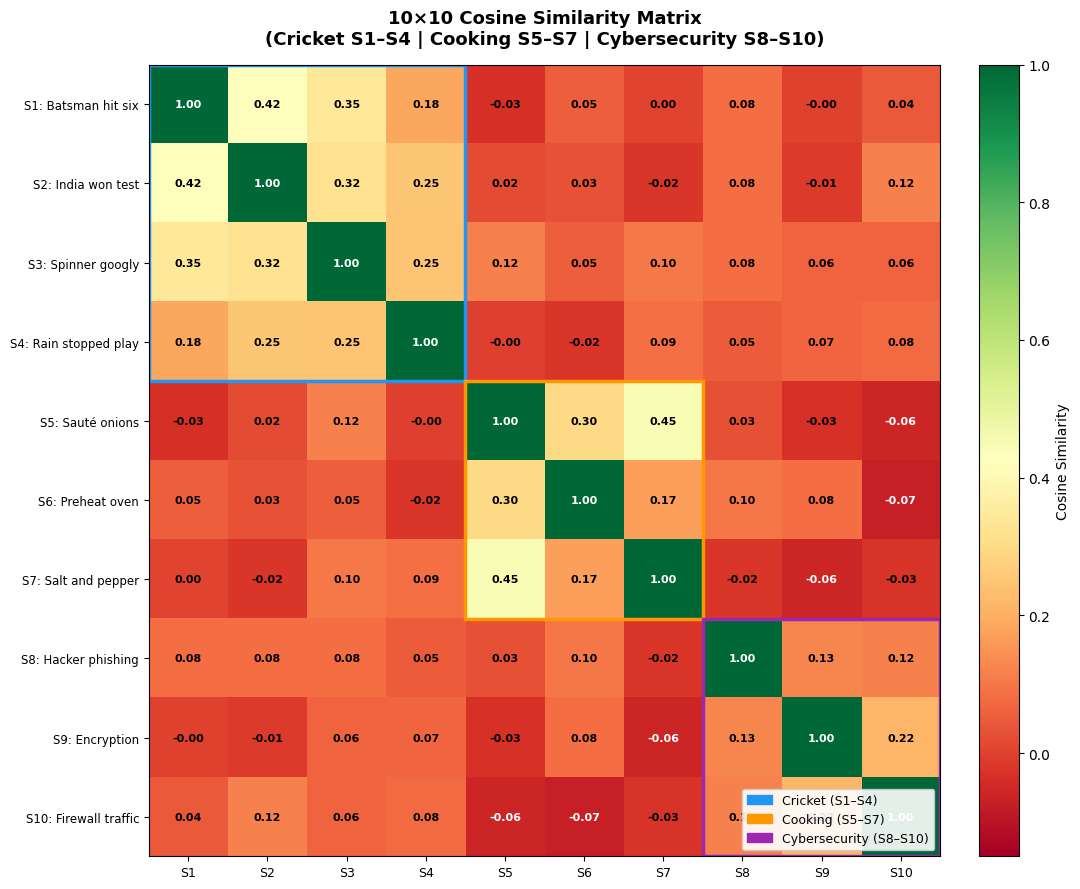

Heatmap saved as similarity_heatmap.png


In [13]:
short_labels = [
    "S1: Batsman hit six",
    "S2: India won test",
    "S3: Spinner googly",
    "S4: Rain stopped play",
    "S5: Sauté onions",
    "S6: Preheat oven",
    "S7: Salt and pepper",
    "S8: Hacker phishing",
    "S9: Encryption",
    "S10: Firewall traffic",
]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=-0.15, vmax=1.0)

# Annotate each cell with its value
for i in range(10):
    for j in range(10):
        val = sim_matrix[i, j]
        color = "white" if val > 0.85 or val < -0.04 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=color, fontweight="bold")

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([f"S{i+1}" for i in range(10)], fontsize=9)
ax.set_yticklabels(short_labels, fontsize=8.5)
ax.set_title(
    "10×10 Cosine Similarity Matrix\n"
    "(Cricket S1–S4 | Cooking S5–S7 | Cybersecurity S8–S10)",
    fontsize=13, fontweight="bold", pad=15
)

# Draw colored border boxes around each topic cluster
for start, end, color, label in [
    (0, 3, "#2196F3", "Cricket"),
    (4, 6, "#FF9800", "Cooking"),
    (7, 9, "#9C27B0", "Cybersecurity"),
]:
    rect = mpatches.FancyBboxPatch(
        (start - 0.5, start - 0.5), end - start + 1, end - start + 1,
        linewidth=2.5, edgecolor=color, facecolor="none",
        boxstyle="square,pad=0"
    )
    ax.add_patch(rect)

# Legend
patches = [
    mpatches.Patch(color="#2196F3", label="Cricket (S1–S4)"),
    mpatches.Patch(color="#FF9800", label="Cooking (S5–S7)"),
    mpatches.Patch(color="#9C27B0", label="Cybersecurity (S8–S10)"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9, framealpha=0.9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Cosine Similarity")
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as similarity_heatmap.png")

In [14]:
query = "The bowler took three wickets in one over."
query_embedding = model.encode([query])
query_sims = cosine_similarity(query_embedding, embeddings)[0]

sorted_idx = np.argsort(query_sims)[::-1]

print(f'Query: "{query}"\n')
print("Similarity scores against all 10 sentences:")
for idx in sorted_idx:
    topic = topic_labels[idx]
    print(f"  [{topic:<13}] S{idx+1:02d} ({query_sims[idx]:+.4f}): {sentences[idx]}")

print()
print("=" * 60)
print("TOP 2 MOST SIMILAR SENTENCES:")
print("-" * 60)
for rank, idx in enumerate(sorted_idx[:2], 1):
    print(f"  Rank {rank} | Score: {query_sims[idx]:.4f} | [{topic_labels[idx]}]")
    print(f'         → "{sentences[idx]}"\n')
print("=" * 60)
print()
print("Interpretation: Both top results are Cricket sentences.")
print("The model correctly identifies semantic similarity even when")
print("the query words ('bowler', 'wickets') don't appear in the")
print("matched sentences — that's the power of dense embeddings.")

Query: "The bowler took three wickets in one over."

Similarity scores against all 10 sentences:
  [Cricket      ] S02 (+0.5633): India won the test match by an innings and 50 runs.
  [Cricket      ] S03 (+0.5354): The spinner bowled a perfect googly to dismiss the opener.
  [Cricket      ] S01 (+0.5138): The batsman hit a six over the boundary rope.
  [Cricket      ] S04 (+0.2989): Rain interrupted play on the third day of the match.
  [Cooking      ] S05 (+0.0880): Sauté the onions in olive oil until they turn golden brown.
  [Cybersecurity] S08 (+0.0831): The hacker used a phishing email to steal login credentials.
  [Cooking      ] S06 (+0.0739): Preheat the oven to 180 degrees before placing the cake inside.
  [Cooking      ] S07 (+0.0613): Add a pinch of salt and freshly ground pepper to the soup.
  [Cybersecurity] S10 (+0.0232): A firewall monitors and filters incoming and outgoing network traffic.
  [Cybersecurity] S09 (+0.0176): End-to-end encryption ensures only the sender an